LAB 6

EXPERIMENT 1: K-NEAREST NEIGHBOUR (KNN)

Q1. Load dataset and split into training & testing sets

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis=1),
    df['target'],
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


Q2. Train KNN classifier

In [2]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

Q3. Predict class labels

In [3]:
knn_pred = knn_model.predict(X_test)
knn_pred_proba = knn_model.predict_proba(X_test)[:, 1]

Q4. Evaluate model

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, knn_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, knn_pred))

print("\nClassification Report:\n",
      classification_report(y_test, knn_pred, target_names=data.target_names))

Accuracy: 0.956140350877193

Confusion Matrix:
 [[38  5]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       1.00      0.88      0.94        43
      benign       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



Q5. Precision-Recall Curve

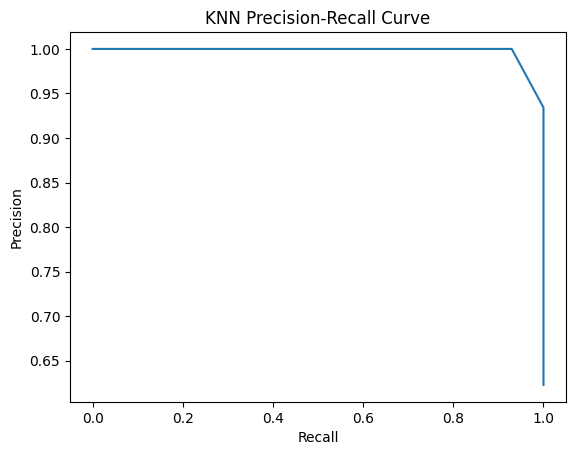

In [5]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, knn_pred_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("KNN Precision-Recall Curve")
plt.show()

EXPERIMENT 2: SUPPORT VECTOR MACHINE (SVM)

Q1. Use same dataset (already loaded & split)

In [6]:
# Reuse X_train, X_test, y_train, y_test

Q2. Train SVM classifier

In [7]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=42)

Q3. Predict class labels

In [8]:
svm_pred = svm_model.predict(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)[:, 1]

Q4. Evaluate model

In [9]:
print("Accuracy:", accuracy_score(y_test, svm_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_pred))

print("\nClassification Report:\n",
      classification_report(y_test, svm_pred, target_names=data.target_names))

Accuracy: 0.956140350877193

Confusion Matrix:
 [[39  4]
 [ 1 70]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



Q5. Precision-Recall Curve

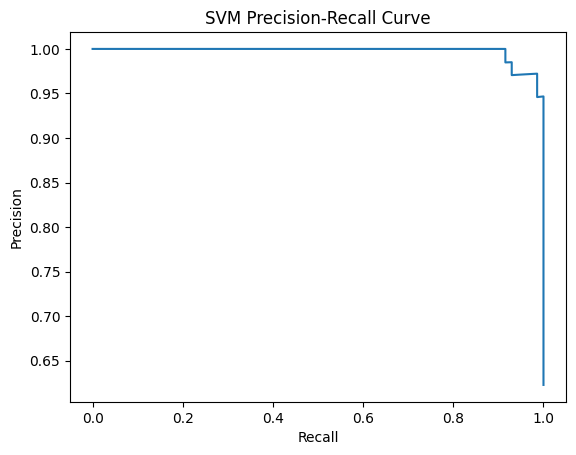

In [10]:
precision_svm, recall_svm, _ = precision_recall_curve(y_test, svm_pred_proba)

plt.plot(recall_svm, precision_svm)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SVM Precision-Recall Curve")
plt.show()

EXPERIMENT 3: MODEL COMPARISON

Q1. Compare accuracy using bar chart

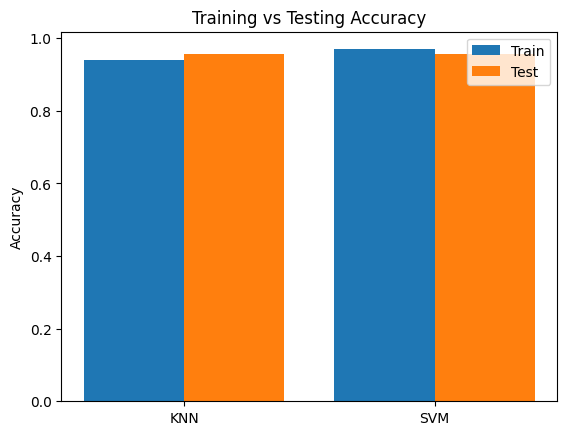

In [11]:
import numpy as np

labels = ['KNN', 'SVM']

train_acc = [
    accuracy_score(y_train, knn_model.predict(X_train)),
    accuracy_score(y_train, svm_model.predict(X_train))
]

test_acc = [
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, svm_pred)
]

x = np.arange(len(labels))

plt.bar(x-0.2, train_acc, 0.4, label='Train')
plt.bar(x+0.2, test_acc, 0.4, label='Test')

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.show()

Q2. ROC Curve Comparison

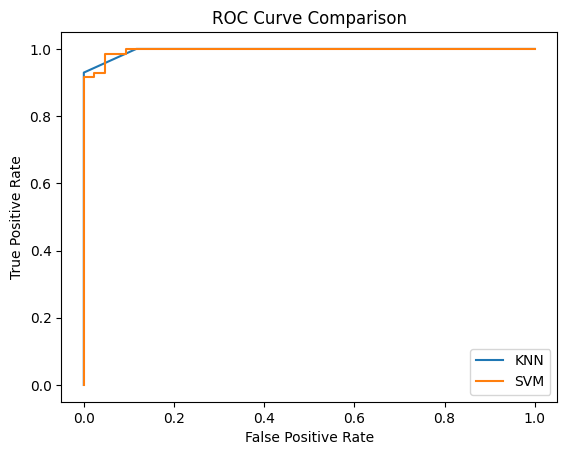

In [12]:
from sklearn.metrics import roc_curve, auc

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_pred_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_pred_proba)

plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

Q3. Confusion Matrix Heatmaps

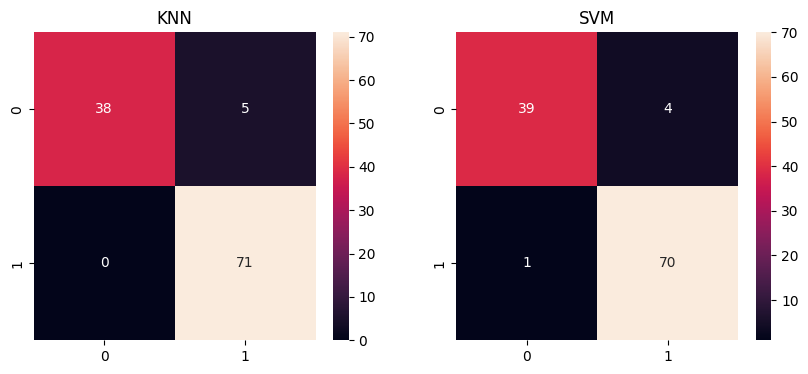

In [13]:
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True)
plt.title("KNN")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True)
plt.title("SVM")

plt.show()